# Simulate a lensed primary CMB temperature map

Generate an **unlensed** primary CMB $T$ map from a CAMB $C_\ell^{TT}$ spectrum at the
FLAMINGO fiducial (DES Y3) cosmology, then **deflect** it with the Yang et al. (2026)
HEALPix convergence map using [`pixell.lensing.lens_map_curved`](https://pixell.readthedocs.io).

Pipeline:

1. CAMB $\rightarrow$ unlensed scalar $C_\ell^{TT}$ in $\mu\mathrm{K}^2$
2. `healpy.synalm` $\rightarrow$ unlensed $a_{\ell m}^{T}$
3. Load FLAMINGO $\kappa$ $\rightarrow$ `map2alm` $\rightarrow$ $\phi_{\ell m}$ via
   `pixell.lensing.kappa_to_phi` ($\phi_{\ell m} = 2\kappa_{\ell m}/[\ell(\ell+1)]$)
4. `pixell.lensing.lens_map_curved` on a full-sky CAR grid
5. Reproject lensed $T$ back to HEALPix ($\mu\mathrm{K}_\mathrm{CMB}$)

> **Kernel**: `cosmo_env` (needs `camb`, `pixell`, `healpy`, `h5py`).  
> Toggle `USE_DOWNGRADE` for a fast $N_\mathrm{side}=256$ preview vs native $4096$.

In [11]:
from pathlib import Path

import camb
import h5py
import healpy as hp
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from pixell import enmap, lensing, reproject

# ---------------------------------------------------------------------------
# Global controls
# ---------------------------------------------------------------------------
DATA_DIR = Path(
    "/home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo"
    "/L2p8_m9/integrated_maps/yang26/lightcone0_shells"
)
OUT_DIR = Path(
    "/home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo"
    "/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated"
)
KAPPA_FILE = DATA_DIR / "CMB_lensing_rot_same_rot.hdf5"

NSIDE_FULL = 4096
NSIDE_DOWNGRADE = 256
USE_DOWNGRADE = False          # True -> Nside=256 preview; False -> native 4096
NSIDE = NSIDE_DOWNGRADE if USE_DOWNGRADE else NSIDE_FULL
LMAX = 3 * NSIDE - 1
SEED = 42                     # RNG seed for unlensed CMB realization

assert KAPPA_FILE.is_file(), f"Missing kappa map: {KAPPA_FILE}"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"USE_DOWNGRADE={USE_DOWNGRADE} -> Nside={NSIDE}, lmax={LMAX}")

USE_DOWNGRADE=False -> Nside=4096, lmax=12287


In [12]:
# Publication-style plots (LaTeX)
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "legend.frameon": False,
})

## 1. Fiducial cosmology (FLAMINGO D3A / DES Y3)

Parameters from Schaye et al. (2023) / Yang et al. (2026), Table 1 — **D3A (fiducial)**:

| Parameter | Value |
|-----------|-------|
| $h$ | $0.681$ |
| $\Omega_\mathrm{m}$ | $0.306$ |
| $\Omega_\mathrm{b}$ | $0.0486$ |
| $\sum m_\nu$ | $0.06\,\mathrm{eV}$ |
| $A_s$ | $2.099\times 10^{-9}$ |
| $n_s$ | $0.967$ |
| $\sigma_8$ | $0.807$ |

Running CAMB...


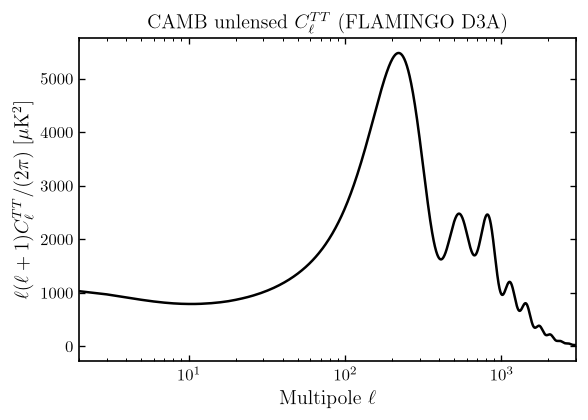

C_ell^TT[2]=1079.058, C_ell^TT[100]=1.6058 uK^2


In [13]:
COSMO = dict(
    h=0.681,
    Om=0.306,
    Ob=0.0486,
    mnu=0.06,
    As=2.099e-9,
    ns=0.967,
)


def camb_unlensed_cltt(lmax: int, cosmo: dict = COSMO) -> np.ndarray:
    """Return unlensed scalar C_ell^TT in uK^2, length lmax+1."""
    h, Om, Ob = cosmo["h"], cosmo["Om"], cosmo["Ob"]
    Oc = Om - Ob
    pars = camb.CAMBparams()
    pars.set_cosmology(
        H0=100.0 * h,
        ombh2=Ob * h**2,
        omch2=Oc * h**2,
        mnu=cosmo["mnu"],
        omk=0.0,
    )
    pars.InitPower.set_params(As=cosmo["As"], ns=cosmo["ns"])
    # Request slightly higher lmax so the spectrum is accurate up to LMAX
    pars.set_for_lmax(max(lmax + 500, 3000), lens_potential_accuracy=0)
    results = camb.get_results(pars)
    powers = results.get_cmb_power_spectra(pars, CMB_unit="muK", raw_cl=True)
    cltt = powers["unlensed_scalar"][:, 0]
    return cltt[: lmax + 1]


print("Running CAMB...")
cltt = camb_unlensed_cltt(LMAX)
ell = np.arange(cltt.size)
dltt = ell * (ell + 1.0) * cltt / (2.0 * np.pi)

fig, ax = plt.subplots(figsize=(5.0, 3.6))
ax.plot(ell[2:], dltt[2:], color="k", lw=1.5)
ax.set_xlim(2, min(LMAX, 3000))
ax.set_xlabel(r"Multipole $\ell$")
ax.set_ylabel(r"$\ell(\ell+1)C_\ell^{TT}/(2\pi)\;[\mu\mathrm{K}^{2}]$")
ax.set_title(r"CAMB unlensed $C_\ell^{TT}$ (FLAMINGO D3A)")
ax.set_xscale("log")
fig.tight_layout()
plt.show()
print(f"C_ell^TT[2]={cltt[2]:.3f}, C_ell^TT[100]={cltt[100]:.4f} uK^2")

## 2. Load FLAMINGO $\kappa$ and convert to $\phi_{\ell m}$

In the Born approximation,

$$
\kappa = \tfrac12\,\nabla^2\phi
\quad\Rightarrow\quad
\phi_{\ell m} = \frac{2\,\kappa_{\ell m}}{\ell(\ell+1)}
\qquad(\ell\ge 2).
$$

In [14]:
print(f"Loading {KAPPA_FILE.name}...")
with h5py.File(KAPPA_FILE, "r") as f:
    kappa = f["data"][:].astype(np.float64)

if kappa.size != 12 * NSIDE_FULL**2:
    raise ValueError(f"Unexpected kappa size {kappa.size}")

if USE_DOWNGRADE:
    kappa = hp.ud_grade(kappa, NSIDE)

kappa = kappa - np.mean(kappa)
print(f"kappa: Nside={hp.npix2nside(kappa.size)}, std={kappa.std():.5f}")

print("Spherical harmonic transform of kappa...")
kappa_alm = hp.map2alm(kappa, lmax=LMAX, iter=3)
phi_alm = lensing.kappa_to_phi(kappa_alm)
# Monopole/dipole of phi are ill-defined; zero them for safety
phi_alm[0:3] = 0.0
print(f"phi_alm size = {phi_alm.size}")

Loading CMB_lensing_rot_same_rot.hdf5...
kappa: Nside=4096, std=0.07730
Spherical harmonic transform of kappa...
phi_alm size = 75503616


## 3. Draw an unlensed primary CMB realization

Gaussian random field from CAMB $C_\ell^{TT}$ (temperature only, $\mu\mathrm{K}_\mathrm{CMB}$).

In [15]:
np.random.seed(SEED)
cmb_alm = hp.synalm(cltt, lmax=LMAX, new=True)
t_unlensed_hp = hp.alm2map(cmb_alm, nside=NSIDE, pixwin=False)
print(
    f"Unlensed T: mean={t_unlensed_hp.mean():.4f} uK, "
    f"std={t_unlensed_hp.std():.2f} uK"
)

Unlensed T: mean=-0.0000 uK, std=107.72 uK


## 4. Lens with `pixell.lensing.lens_map_curved`

Full-sky CAR geometry with resolution $\Delta\theta = \pi/(2N_\mathrm{side})$ (compatible with
pixell SHTs). `output='lu'` returns **(lensed, unlensed)** CAR maps; we then reproject to
HEALPix with `reproject.map2healpix`.

In [16]:
# CAR pixelization: ny = 2*Nside, nx = 4*Nside when res = pi/(2*Nside)
shape, wcs = enmap.fullsky_geometry(res=np.pi / (2 * NSIDE))
print(f"CAR geometry: shape={shape}")

print("Lensing CMB (pixell.lens_map_curved)...")
# cmb_alm shape (ncomp, nalm); spin=0 for temperature-only
lensed_car, unlensed_car = lensing.lens_map_curved(
    shape,
    wcs,
    phi_alm,
    cmb_alm[None],
    output="lu",
    spin=0,
    verbose=True,
)

print("Reprojecting to HEALPix...")
t_lensed_hp = reproject.map2healpix(
    lensed_car, nside=NSIDE, lmax=LMAX, method="harm", spin=0
)
# map2healpix returns shape (npix,) for a 2D enmap
t_lensed_hp = np.asarray(t_lensed_hp).reshape(-1)

print(
    f"Lensed T: mean={t_lensed_hp.mean():.4f} uK, "
    f"std={t_lensed_hp.std():.2f} uK"
)
print(
    f"Residual std (lensed - unlensed) = "
    f"{(t_lensed_hp - t_unlensed_hp).std():.3f} uK"
)

CAR geometry: shape=(np.int64(8192), np.int64(16384))
Lensing CMB (pixell.lens_map_curved)...
Computing grad map


/home/ext_andyxlcnb_gmail_com/envs/cosmo_env/lib/python3.12/site-packages/pixell/lensing.py:444: UserWarning: In the future, the default will be switched to lenspyx
  warnings.warn('In the future, the default will be switched to lenspyx')


Computing observed coordinates
Computing alpha map
Computing unlensed map
Computing lensed map
Reprojecting to HEALPix...
Lensed T: mean=-0.0260 uK, std=107.71 uK
Residual std (lensed - unlensed) = 21.435 uK


## 5. Visualize maps


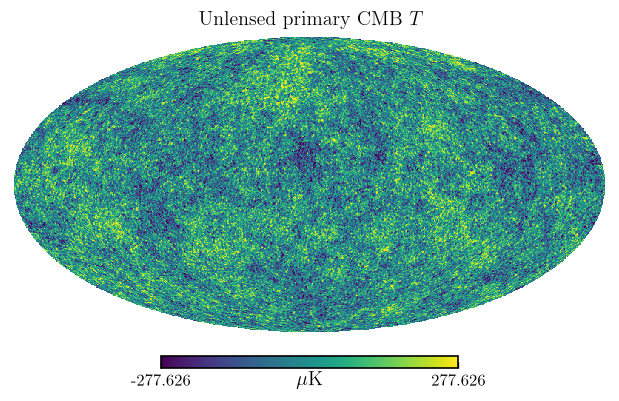

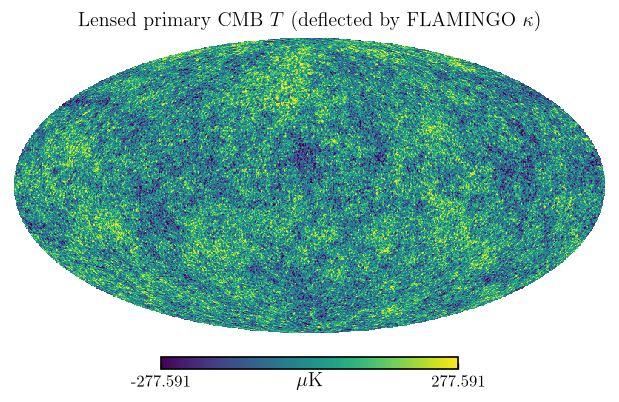

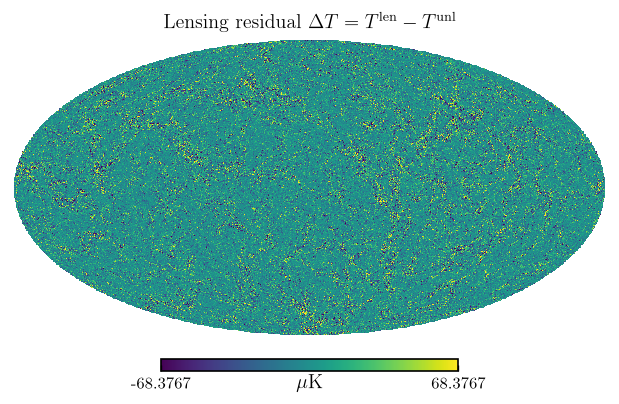

In [17]:
def mollview_T(m, title):
    vmax = np.percentile(np.abs(m), 99)
    hp.mollview(m, title=title, unit=r"$\mu\mathrm{K}$", min=-vmax, max=vmax, hold=True)
    plt.show()


mollview_T(t_unlensed_hp, r"Unlensed primary CMB $T$")
mollview_T(t_lensed_hp, r"Lensed primary CMB $T$ (deflected by FLAMINGO $\kappa$)")
mollview_T(
    t_lensed_hp - t_unlensed_hp,
    r"Lensing residual $\Delta T = T^{\mathrm{len}} - T^{\mathrm{unl}}$",
)

## 6. Save maps

Writes HEALPix FITS maps in $\mu\mathrm{K}_\mathrm{CMB}$ (RING ordering).

In [18]:
tag = f"nside{NSIDE}_seed{SEED}"
path_unl = OUT_DIR / f"primary_CMB_T_unlensed_{tag}.fits"
path_len = OUT_DIR / f"primary_CMB_T_lensed_{tag}.fits"
path_kap = OUT_DIR / f"kappa_used_{tag}.fits"

hp.write_map(path_unl, t_unlensed_hp, overwrite=True, dtype=np.float64,
             column_names=["TEMPERATURE"], extra_header=[("UNIT", "uK_CMB")])
hp.write_map(path_len, t_lensed_hp, overwrite=True, dtype=np.float64,
             column_names=["TEMPERATURE"], extra_header=[("UNIT", "uK_CMB")])
hp.write_map(path_kap, kappa, overwrite=True, dtype=np.float64,
             column_names=["KAPPA"])

# Also store CAMB spectrum for reproducibility
np.savez(
    OUT_DIR / f"camb_cltt_unlensed_{tag}.npz",
    ell=np.arange(cltt.size),
    cltt=cltt,
    cosmo=COSMO,
    lmax=LMAX,
    nside=NSIDE,
    seed=SEED,
)

print("Wrote:")
for p in (path_unl, path_len, path_kap):
    print(f"  {p}")

Wrote:
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/primary_CMB_T_unlensed_nside4096_seed42.fits
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/primary_CMB_T_lensed_nside4096_seed42.fits
  /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/kappa_used_nside4096_seed42.fits


## 7. Unlensed vs lensed CMB power spectra

Publication-quality comparison of $D_\ell=\ell(\ell+1)C_\ell^{TT}/(2\pi)$ for the
unlensed realization and the map lensed by the FLAMINGO $\kappa$ field. The lower
panel shows the ratio $C_\ell^{\mathrm{len}}/C_\ell^{\mathrm{unl}}$.

Wrote /home/ext_andyxlcnb_gmail_com/cosmology_data/flamingo/L2p8_m9/integrated_maps/yang26/lightcone0_shells/simulated/cmb_TT_unlensed_vs_lensed_nside4096_seed42.pdf


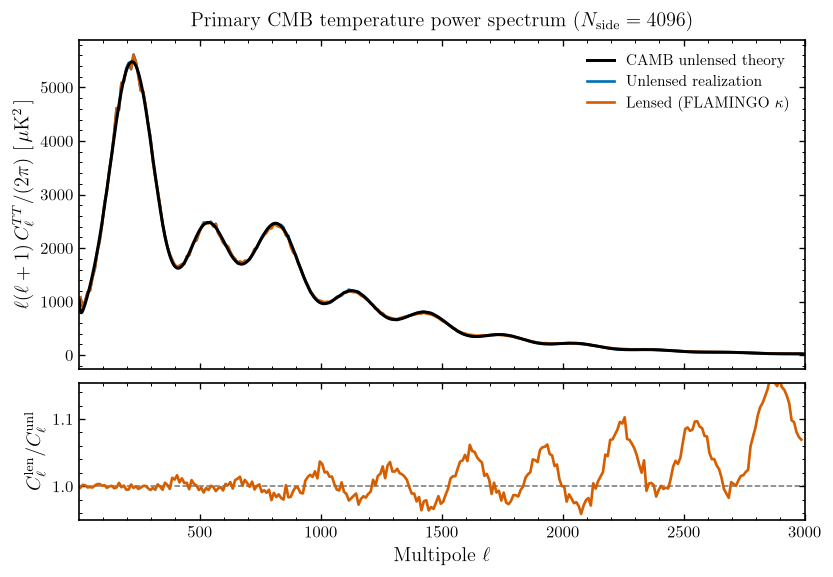

In [21]:
LMAX = 3000
def bin_spectrum(cl: np.ndarray, delta_ell: int = 10) -> tuple[np.ndarray, np.ndarray]:
    """Equal-width bandpowers for display (skip monopole/dipole)."""
    ell = np.arange(cl.size)
    start = 2
    n_bins = (cl.size - start) // delta_ell
    ell_b = np.empty(n_bins)
    cl_b = np.empty(n_bins)
    for i in range(n_bins):
        lo = start + i * delta_ell
        hi = lo + delta_ell
        ell_b[i] = ell[lo:hi].mean()
        cl_b[i] = cl[lo:hi].mean()
    return ell_b, cl_b

cl_unl = hp.anafast(t_unlensed_hp, lmax=LMAX)
cl_len = hp.anafast(t_lensed_hp, lmax=LMAX)
# Note: cltt may come from CAMB with a different length; need a mask compatible with cltt
#         so compute its own ell-th array accordingly.
ell = np.arange(LMAX + 1)
fac = ell * (ell + 1.0) / (2.0 * np.pi)

# === Wider x-range: show up to min(LMAX, 3*NSIDE) (instead of 2*NSIDE) ===
ell_max_plot = min(LMAX, 3 * NSIDE)  # go wider in multipole
mask_ell = (ell >= 2) & (ell <= ell_max_plot)

# Ensure cltt, which could be from CAMB, has separate ell range
cltt_ell = np.arange(cltt.size)
mask_cltt = (cltt_ell >= 2) & (cltt_ell <= ell_max_plot)
fac_cltt = cltt_ell * (cltt_ell + 1.0) / (2.0 * np.pi)

ell_u, cl_u_b = bin_spectrum(cl_unl, delta_ell=10)
ell_l, cl_l_b = bin_spectrum(cl_len, delta_ell=10)
fac_u = ell_u * (ell_u + 1.0) / (2.0 * np.pi)
fac_l = ell_l * (ell_l + 1.0) / (2.0 * np.pi)
keep_u = ell_u <= ell_max_plot
keep_l = ell_l <= ell_max_plot

# Colourblind-friendly palette
c_theory = "#000000"
c_unl = "#0072B2"
c_len = "#D55E00"

fig = plt.figure(figsize=(7.8, 5.2))  # widen figure for more x-range
gs = fig.add_gridspec(2, 1, height_ratios=[2.4, 1.0], hspace=0.06)
ax = fig.add_subplot(gs[0])
axr = fig.add_subplot(gs[1], sharex=ax)

# --- top: D_ell ---
ax.plot(
    cltt_ell[mask_cltt], fac_cltt[mask_cltt] * cltt[mask_cltt],
    color=c_theory, lw=1.8, zorder=3,
    label=r"CAMB unlensed theory",
)
ax.plot(
    ell_u[keep_u], fac_u[keep_u] * cl_u_b[keep_u],
    color=c_unl, lw=1.6, zorder=2,
    label=r"Unlensed realization",
)
ax.plot(
    ell_l[keep_l], fac_l[keep_l] * cl_l_b[keep_l],
    color=c_len, lw=1.6, zorder=2,
    label=r"Lensed (FLAMINGO $\kappa$)",
)

ax.set_ylabel(r"$\ell(\ell+1)\,C_\ell^{TT}/(2\pi)\ [\,\mu\mathrm{K}^{2}\,]$")
ax.set_xlim(2, ell_max_plot)
ax.tick_params(labelbottom=False)
ax.legend(loc="upper right", frameon=False, handlelength=1.8, borderaxespad=0.6)
ax.set_title(
    r"Primary CMB temperature power spectrum"
    + (rf" ($N_{{\mathrm{{side}}}}={NSIDE}$)" if not USE_DOWNGRADE
       else rf" ($N_{{\mathrm{{side}}}}={NSIDE}$, downgraded)"),
    pad=8,
)

# --- bottom: ratio ---
ratio = np.divide(cl_l_b, cl_u_b, out=np.full_like(cl_l_b, np.nan), where=cl_u_b > 0)
axr.axhline(1.0, color="0.45", lw=0.9, ls="--", zorder=1)
axr.plot(
    ell_l[keep_l], ratio[keep_l],
    color=c_len, lw=1.6, zorder=2,
)
axr.set_xlabel(r"Multipole $\ell$")
axr.set_ylabel(r"$C_\ell^{\mathrm{len}}/C_\ell^{\mathrm{unl}}$")
# Lensing typically boosts small-scale power by a few percent
ymin = min(0.95, np.nanpercentile(ratio[keep_l], 2) - 0.01)
ymax = max(1.12, np.nanpercentile(ratio[keep_l], 98) + 0.01)
axr.set_ylim(ymin, ymax)

for a in (ax, axr):
    a.minorticks_on()
    a.tick_params(which="both", direction="in", top=True, right=True)

fig_path = OUT_DIR / f"cmb_TT_unlensed_vs_lensed_nside{NSIDE}_seed{SEED}"
fig.savefig(f"{fig_path}.pdf")
fig.savefig(f"{fig_path}.png")
print(f"Wrote {fig_path}.pdf")
plt.show()

## Notes

1. **Temperature only** — polarization (Q/U) can be added later by generating TEB alms and
   passing `spin=[0, 2]` into `lens_map_curved`.
2. **Resolution** — for publication-quality lensing of the native $\kappa$ map, set
   `USE_DOWNGRADE=False` ($N_\mathrm{side}=4096$). This needs substantial RAM/CPU.
3. **Method** — pixell warns that the default curved-sky method will switch to `lenspyx`;
   you can pass `method='lenspyx'` after `uv pip install lenspyx` for higher accuracy.
4. **Next step** — add frequency-dependent secondaries:
   $T(\nu)=T_\mathrm{CMB}^{\mathrm{len}}+T_\mathrm{CMB}\,y\,f(\nu)+T_\mathrm{kSZ}+T_\mathrm{CIB}(\nu)$.

### References

1. Yang et al. (2026), MNRAS 548 — FLAMINGO secondary CMB maps / $\kappa$
2. Schaye et al. (2023) — FLAMINGO D3A cosmology
3. Lewis & Challinor (2006) — CMB lensing review
4. [pixell](https://github.com/simonsobs/pixell) — `lensing.lens_map_curved`, `kappa_to_phi`